In [20]:
%matplotlib inline
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.io as pio

# Use notebook-connected renderer so Plotly figures display in Jupyter
pio.renderers.default = 'notebook_connected'

from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
import cvxpy as cp
from datetime import datetime

import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.covariance import GraphicalLasso

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Animated Mahalanobis helper (module-level)
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import re


In [21]:
"""
Configuration: ticker lists and name mapping

This section defines the asset universe used in the examples (sector ETFs
or representative tickers) and a human-readable `NAME_MAP`. The lists are
referenced by later functions that align shocks and build reports.
"""

# ---------------------------------------------------------
# 1. CONFIG: Sector tickers only (US, EU, CN)
# ---------------------------------------------------------

SECTOR_TICKERS = {
    'US_FIN':  'XLF',
    'US_UTIL': 'XLU',
    'US_MAT':  'XLB',
    'EU_FIN':  'EUFN',
    'EU_UTIL': 'EXH1.DE',
    'EU_MAT':  'EXV3.DE',
    'CN_FIN':  '159931.SZ',
    'CN_UTIL': '^107570-USD-STRD',
    'CN_MAT':  '^107541-USD-STRD',
}

ALL_TICKERS = list(SECTOR_TICKERS.values())

NAME_MAP = {
    'XLF': 'US Fin',
    'XLU': 'US Util',
    'XLB': 'US Mat',
    'EUFN': 'EU Fin',
    'EXH1.DE': 'EU Util',
    'EXV3.DE': 'EU Mat',
    '159931.SZ': 'CN Fin',
    '^107570-USD-STRD': 'CN Util',
    '^107541-USD-STRD': 'CN Mat',
}

In [22]:
# ---------------------------------------------------------
# 1. CONFIG: Sector tickers only (US, EU, CN)
# ---------------------------------------------------------

SECTOR_TICKERS = {
    'US_FIN':  'XLF',
    'US_UTIL': 'XLU',
    'US_MAT':  'XLB',
    'EU_FIN':  'EUFN',
    'EU_UTIL': 'EXH1.DE',
    'EU_MAT':  'EXV3.DE',
    'CN_FIN':  '159931.SZ',
    'CN_UTIL': '^107570-USD-STRD',
    'CN_MAT':  '^107541-USD-STRD',
}

ALL_TICKERS = list(SECTOR_TICKERS.values())

NAME_MAP = {
    'XLF': 'US Fin',
    'XLU': 'US Util',
    'XLB': 'US Mat',
    'EUFN': 'EU Fin',
    'EXH1.DE': 'EU Util',
    'EXV3.DE': 'EU Mat',
    '159931.SZ': 'CN Fin',
    '^107570-USD-STRD': 'CN Util',
    '^107541-USD-STRD': 'CN Mat',
}

In [23]:
# Sector-specific relative severity bands (absolute shock deviation allowed)
# You can tune these freely per ticker or per sector group.
SEVERITY_BANDS = {
    # US
    'XLF': 0.100,   # Fin
    'XLU': 0.100,   # Util
    'XLB': 0.100,   # Mat (more flexible, higher uncertainty)
    # EU
    'EUFN': 0.100,
    'EXH1.DE': 0.100,
    'EXV3.DE': 0.100,
    # CN
    '159931.SZ': 0.100,  # maybe looser for EM-like markets
    '^107570-USD-STRD': 0.100,
    '^107541-USD-STRD': 0.100,
    
  
}

In [24]:
"""
Data download and returns calculation

- `download_price_data`: fetches adjusted close prices and drops rows
  with missing data. If a ticker download fails (all-NaN column) it is
  removed so the notebook can continue.
- `compute_log_returns`: computes simple log-return approximation on a
  weekly cadence (shift by 5 trading days). Adjust `freq` logic if you
  need a different periodicity.
"""

# ---------------------------------------------------------
# 2. Download prices & compute returns
# ---------------------------------------------------------


def download_price_data(tickers, start='2023-11-04', end=None, retries=2):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')

    # Try a couple times in case of transient network issues
    last_exc = None
    for attempt in range(retries):
        try:
            data = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']
            break
        except Exception as e:
            last_exc = e
    else:
        # Final attempt without suppressing the exception
        data = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']

    # Ensure DataFrame shape
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Drop any tickers that returned all-NaN (failed download)
    data = data.dropna(axis=1, how='all')

    # Drop rows with any remaining NaNs (align on common dates)
    data = data.dropna(how='any')

    return data





In [25]:
def compute_log_returns(prices, freq='D'):
    log_prices = np.log(prices)
    log_ret = log_prices - log_prices.shift(5)
    log_ret = log_ret.dropna()
    return log_ret

In [26]:
# Example usage: download prices (uses existing download_price_data) and compute both series
prices = download_price_data(ALL_TICKERS)
rets_daily = compute_log_returns(prices, freq='D')


# quick inspection
print("Daily log returns:", rets_daily.shape)
print(rets_daily.head())


[*********************100%***********************]  9 of 9 completed

Daily log returns: (492, 9)
Ticker      159931.SZ      EUFN   EXH1.DE   EXV3.DE       XLB       XLF  \
Date                                                                      
2023-11-13  -0.024181  0.013252 -0.003164  0.033928 -0.014777  0.005330   
2023-11-14  -0.017224  0.042493  0.018817  0.036093  0.033888  0.025541   
2023-11-15  -0.002070  0.039671  0.026791  0.054915  0.035163  0.029844   
2023-11-16  -0.002768  0.041313 -0.006616  0.038549  0.046758  0.038039   
2023-11-17   0.000696  0.052168  0.007245  0.046499  0.036926  0.031923   

Ticker           XLU  ^107541-USD-STRD  ^107570-USD-STRD  
Date                                                      
2023-11-13 -0.034628         -0.036898         -0.016591  
2023-11-14  0.011848         -0.014333          0.004350  
2023-11-15  0.016152          0.026044          0.030723  
2023-11-16  0.034723          0.028123          0.025828  
2023-11-17  0.032137          0.041847          0.027709  


In [27]:
# Target Mahalanobis radius (roughly "joint σ-level" under crisis covariance)
TARGET_MAHALANOBIS = 5.0
MAHAL_TOL = 5  # allow +/- 0.5 band around target

In [28]:



def cov_sample_(returns, decay):
    X = returns.values
    T = X.shape[0]
    if decay is None or decay == 1.0:
        return np.cov(X, rowvar=False)
    # exponential weights: newest obs has highest weight
    weights = decay ** np.arange(T-1, -1, -1)
    weights = weights / weights.sum()
    mu = (weights[:, None] * X).sum(axis=0)
    Xc = X - mu
    S = (Xc.T * weights) @ Xc
    # unbiased adjustment for normalized weights
    denom = 1.0 - np.sum(weights ** 2)
    if denom <= 0:
        return S
    return S / denom

# Shrinkage Covariance LedoitWolf
def cov_sample_ledoit(rets):
    X = rets.values
    lw = LedoitWolf().fit(X)
    return lw.covariance_

# M estimator Huber covariance

def cov_huber(returns, c=1.5, tol=1e-6, max_iter=200):
    X = returns.values
    T, N = X.shape
    mu = X.mean(axis=0)
    S = np.cov(X, rowvar=False)

    for _ in range(max_iter):
        diff = X - mu
        d2 = np.sum(diff @ np.linalg.inv(S) * diff, axis=1)
        w = np.minimum(1, c / np.sqrt(d2 + 1e-12))
        W = np.diag(w)
        S_new = (diff.T @ W @ diff) / np.sum(w)
        if np.linalg.norm(S_new - S) < tol:
            break
        S = S_new

    return S

# M Estimator Student-t Covariance
def cov_student_t(returns, nu=5, tol=1e-6, max_iter=200):
    """
    Student-t covariance estimator (robust M-estimator).
    """
    X = returns.values if hasattr(returns, "values") else returns
    T, N = X.shape

    mu = X.mean(axis=0)
    Sigma = np.cov(X, rowvar=False)

    for _ in range(max_iter):
        Sigma_inv = np.linalg.inv(Sigma)
        diff = X - mu
        d2 = np.sum(diff @ Sigma_inv * diff, axis=1)

        w = (nu + N) / (nu + d2)
        Sigma_new = (diff.T * w) @ diff / T

        if np.linalg.norm(Sigma_new - Sigma) < tol:
            Sigma = Sigma_new
            break

        Sigma = Sigma_new

    return Sigma, mu

# add Graphoical Lasso covariance

def cov_graphical_lasso(returns, alpha=0.01, max_iter=200):
    X = returns.values
    model = GraphicalLasso(alpha=alpha, max_iter=max_iter)
    model.fit(X)
    return model.covariance_


# Simple shrinkage toward the identity for M estimator

def shrink_covariance(S_m, shrinkage):
    N = S_m.shape[0]
    T = np.trace(S_m) / N * np.eye(N)
    return (1 - shrinkage) * S_m + shrinkage * T



In [29]:
#PA‑RCV covariance estimator

def rcv_single_split(X, train_idx, test_idx):
    """
    RCV for a single train/test split.
    """
    X_train = X[train_idx]
    X_test  = X[test_idx]

    # Sample covariance on training set
    S_train = np.cov(X_train, rowvar=False)

    # Prediction error on test set
    # Frobenius risk proxy: E[(x x' - S)^2]
    errors = []
    for x in X_test:
        xx = np.outer(x, x)
        errors.append((xx - S_train) ** 2)

    # Average error matrix
    E = np.mean(errors, axis=0)

    # Refitted covariance = S_train - E (thresholded at 0)
    S_refit = S_train - E
    S_refit = np.maximum(S_refit, 0)  # ensure PSD-ish

    return S_refit


def permutation_averaged_rcv(returns, K=50, train_frac=0.7, random_state=0):
    """
    Permutation-Averaged Refitted Cross-Validation covariance estimator.
    
    Parameters
    ----------
    returns : DataFrame or ndarray (T x N)
    K : number of permutations
    train_frac : fraction of data used for training
    random_state : reproducibility
    
    Returns
    -------
    Sigma_parcv : NxN covariance matrix
    """
    rng = np.random.default_rng(random_state)
    X = returns.values if hasattr(returns, "values") else returns
    T, N = X.shape

    covs = []

    for _ in range(K):
        perm = rng.permutation(T)
        train_size = int(train_frac * T)

        train_idx = perm[:train_size]
        test_idx  = perm[train_size:]

        S_refit = rcv_single_split(X, train_idx, test_idx)
        covs.append(S_refit)

    # Average over permutations
    Sigma_parcv = np.mean(covs, axis=0)

    # Force symmetry
    Sigma_parcv = 0.5 * (Sigma_parcv + Sigma_parcv.T)

    return Sigma_parcv


In [30]:
"""
Paper shocks

Defines a small dictionary of example sector shocks (paper / narrative
shocks). Returned as a vector aligned with `ALL_TICKERS` so downstream
optimization can reference them directly.
"""

def build_paper_shocks():
    # Example ISDA-style / climate transition shocks (1y, unreal)
    shocks = {
        'XLF': -0.20,
        'XLU': -0.15,
        'XLB': -0.30,
        'EUFN': -0.18,
        'EXH1.DE': -0.14,
        'EXV3.DE': -0.25,
        '159931.SZ': -0.12,
        '^107570-USD-STRD': -0.10,
        '^107541-USD-STRD': -0.20,
    }
    return np.array([shocks[t] for t in ALL_TICKERS])


In [31]:
"""
Optimization of scenario shocks under a Mahalanobis constraint

- Variables: shock vector `s` (length N)
- Objective: keep `s` close to narrative `s0` (least-squares)
- Constraints: all shocks non-positive, optional ordering constraints,
    severity-band per-ticker constraints, and an upper-bound on Mahalanobis radius (convex constraint).

The solver returns the optimized shock vector and achieved squared
Mahalanobis radius.
"""

def optimize_shocks(cov, s0, active_tickers):
        n = len(s0)
        s = cp.Variable(n)
        mu = np.zeros(n)

        Sigma_inv = np.linalg.inv(cov)
        r2 = cp.quad_form(s - mu, Sigma_inv)

        obj = cp.Minimize(cp.sum_squares(s - s0))
        constraints = []

        # All shocks non-positive
        constraints.append(s <= 0)

        # Per-ticker severity bands (absolute deviation allowed from narrative s0)
        # SEVERITY_BANDS is defined at module level as absolute allowed deviation
        for i, t in enumerate(active_tickers):
                if t in SEVERITY_BANDS:
                        band = SEVERITY_BANDS[t]
                        constraints.append(s[i] >= s0[i] - band)
                        constraints.append(s[i] <= s0[i] + band)

       

        # Preserve the relative ordering of shocks from the narrative s0:
        # if ticker i has s0[i] <= s0[j] then enforce s[i] <= s[j]
        # (allows equals; avoids changing ranking of shocks by value)
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                try:
                    if s0[i] <= s0[j]:
                        constraints.append(s[i] <= s[j])
                except Exception:
                    # numeric guard; skip if comparison fails
                    pass

        # Mahalanobis radius targeting (only an upper bound enforced here)
        target2_min = (TARGET_MAHALANOBIS - MAHAL_TOL) ** 2
        target2_max = (TARGET_MAHALANOBIS + MAHAL_TOL) ** 2
        constraints.append(r2 <= target2_max)

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=cp.SCS, verbose=False)

        if s.value is None:
                raise RuntimeError("Optimization failed")

        achieved_r2 = float((s.value - mu) @ Sigma_inv @ (s.value - mu))
        if achieved_r2 < target2_min:
                print(f"Warning: achieved Mahalanobis radius squared {achieved_r2:.4f} is below target minimum {target2_min:.4f}")

        return s.value, achieved_r2


In [32]:
"""
Plotting utilities

This group of functions produces the visual diagnostics used in the
reports: shock comparison bars, covariance/correlation heatmaps and
supporting helper plots.
"""

# ---------------------------------------------------------
# 6. Plotting
# ---------------------------------------------------------

def plot_shock_comparison(active_tickers, s0, s_opt):
    labels = [NAME_MAP[t] for t in active_tickers]
    x = np.arange(len(labels))
    w = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - w/2, s0 * 100, width=w, label='Paper shocks')
    plt.bar(x + w/2, s_opt * 100, width=w, label='Optimized shocks')

    plt.axhline(0, color='black', linewidth=0.8)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylabel('Shock (%)')
    plt.title('Paper vs Optimized Sector Shocks – US / EU / CN')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [33]:
#heatmap of covariance matrix

def plot_covariance_heatmap(cov_matrix, tickers, show_correlation=False):
    # Ensure perfect symmetry by averaging with transpose (fixes numerical precision issues)
    cov_symmetric = (cov_matrix + cov_matrix.T) / 2
    
    if show_correlation:
        # Convert covariance to correlation matrix
        # corr[i,j] = cov[i,j] / sqrt(cov[i,i] * cov[j,j])
        std_devs = np.sqrt(np.diag(cov_symmetric))
        corr_matrix = cov_symmetric / np.outer(std_devs, std_devs)
        data_to_plot = corr_matrix
        title = "Correlation Matrix Heatmap active model"
        fmt_str = ".2f"
        cmap = "RdBu_r"  # Red-Blue diverging, reversed (blue=positive, red=negative)
        vmin, vmax = -1, 1
    else:
        data_to_plot = cov_symmetric
        title = "Covariance Matrix Heatmap active model"
        fmt_str = ".4f"
        cmap = "coolwarm"
        vmin, vmax = None, None
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(data_to_plot, xticklabels=tickers, yticklabels=tickers, 
                annot=True, fmt=fmt_str, cmap=cmap, square=True,
                vmin=vmin, vmax=vmax, center=0 if show_correlation else None)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [34]:
def compute_mahalanobis_contributions(s, mu, Sigma_inv):
    """
    Returns per-asset contribution to Mahalanobis distance.
    Contribution_i = (s_i - mu_i) * (Sigma_inv @ (s - mu))_i
    """
    x = s - mu
    y = Sigma_inv @ x
    contrib = x * y
    return contrib


In [35]:
def print_summary_table(active_tickers, s0, s_opt, Sigma_inv):
    mu = np.zeros(len(s0))
    contrib = compute_mahalanobis_contributions(s_opt, mu, Sigma_inv)

    df = pd.DataFrame({
        "Ticker": active_tickers,
        "Name": [NAME_MAP[t] for t in active_tickers],
        "Paper Shock": s0,
        "Optimized Shock": s_opt,
        "Delta": s_opt - s0,
        "Mahalanobis Contribution": contrib
    })

    df["Paper Shock"] = df["Paper Shock"].round(4)
    df["Optimized Shock"] = df["Optimized Shock"].round(4)
    df["Delta"] = df["Delta"].round(4)
    df["Mahalanobis Contribution"] = df["Mahalanobis Contribution"].round(6)

    print("\n==================== SUMMARY TABLE ====================\n")
    print(df.to_string(index=False))
    print("\n=======================================================\n")

    return df


In [36]:
def cov_to_corr(cov):
    D = np.sqrt(np.diag(cov))
    return cov / np.outer(D, D)

def plot_corr_heatmaps_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso, tickers):
    mats = [cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso]
    titles = ["Sample covariance", "Sample + shrinkage", "Huber + shrinkage", "StudentT + shrinkage", "PARCV", "GraphLasso"]

    # Convert to correlations for fair visual comparison and use symmetric diverging colormap
    corrs = [cov_to_corr(m) for m in mats]
    abs_max = max(np.abs(c).max() for c in corrs)
    vmin, vmax = -abs_max, abs_max
    cmap = "RdBu_r"
    fmt = ".2f"

    fig, axes = plt.subplots(1, len(mats), figsize=(6 * len(mats), 5))
    for ax, corr, title in zip(axes, corrs, titles):
        sns.heatmap(corr, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, center=0, annot=True, fmt=fmt, square=True, cbar=True)
        ax.set_title(title)
        ax.set_xticklabels(tickers, rotation=45, ha='right')
        ax.set_yticklabels(tickers, rotation=0)

    plt.tight_layout()
    plt.show()


def plot_eigenvalues_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso):
    def safe_eigvals(cov):
        eig = np.linalg.eigvalsh(cov)
        eig = np.real(eig)
        eig = np.nan_to_num(eig, nan=0.0, posinf=np.finfo(float).max/1e6, neginf=0.0)
        return np.sort(eig)[::-1]

    eig_std = safe_eigvals(cov_sample)
    eig_s = safe_eigvals(cov_sample_shrunk)
    eig_h = safe_eigvals(cov_huber_shrunk)
    eig_t = safe_eigvals(cov_student_t_shrunk)
    eig_p = safe_eigvals(cov_parcv)
    eig_g = safe_eigvals(cov_graphLasso)

    # Ensure all series have the same length for plotting
    n = max(len(eig_std), len(eig_s), len(eig_h), len(eig_t), len(eig_p), len(eig_g))
    def pad(arr, target_len):
        if len(arr) < target_len:
            return np.concatenate([arr, np.zeros(target_len - len(arr))])
        return arr

    eig_std = pad(eig_std, n)
    eig_s   = pad(eig_s, n)
    eig_h   = pad(eig_h, n)
    eig_t   = pad(eig_t, n)
    eig_p   = pad(eig_p, n)
    eig_g   = pad(eig_g, n)

    x = np.arange(1, n+1)

    plt.figure(figsize=(10,6))
    plt.plot(x, eig_std, marker='o', linestyle='-', linewidth=2, label="Sample")
    plt.plot(x, eig_s,   marker='s', linestyle='--', linewidth=2, label="Sample+shrink")
    plt.plot(x, eig_h,   marker='^', linestyle='-.', linewidth=2, label="Huber+shrink")
    plt.plot(x, eig_t,   marker='d', linestyle=':', linewidth=2, label="StudentT+shrink")
    plt.plot(x, eig_p,   marker='v', linestyle='-', linewidth=2, label="PARCV")
    plt.plot(x, eig_g,   marker='x', linestyle='--', linewidth=2, label="GraphLasso")
    plt.title("Eigenvalue spectrum")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
def plot_avg_correlatios_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso):
    mats = [cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso]
    labels = ["Sample", "Sample+shrink", "Huber+shrink", "StudentT+shrink", "PARCV", "GraphLasso"]

    def avg_corr(cov):
        c = cov_to_corr(cov)
        return np.mean(c[np.triu_indices_from(c, k=1)])

    vals = [avg_corr(m) for m in mats]

    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(vals)))

    plt.figure(figsize=(10,5))
    plt.bar(range(len(labels)), vals, color=colors)
    plt.xticks(range(len(labels)), labels)
    plt.title("Average correlations")
    plt.ylabel("Mean pairwise correlation")
    for i, v in enumerate(vals):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
    plt.ylim(min(vals) * 0.95, max(vals) * 1.05)
    plt.tight_layout()
    plt.show()
    def avg_corr(cov):
        c = cov_to_corr(cov)
        return np.mean(c[np.triu_indices_from(c, k=1)])

        vals = [
        avg_corr(cov_sample),
        avg_corr(cov_sample_shrunk),
        avg_corr(cov_huber_shrunk),
        avg_corr(cov_student_t_shrunk),
        avg_corr(cov_parcv),
        avg_corr(cov_graphLasso),
        ]
        labels = ["Sample", "Sample+shrink", "Huber+shrink", "StudentT+shrink", "PARCV", "GraphLasso"]

        cmap = plt.cm.viridis
        colors = cmap(np.linspace(0, 1, len(vals)))

        plt.figure(figsize=(8,5))
        plt.bar(range(len(labels)), vals, color=colors)
        plt.xticks(range(len(labels)), labels)
        plt.title("Average correlations")
        plt.ylabel("Mean pairwise correlation")
        for i, v in enumerate(vals):
         plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
        plt.ylim(min(vals) * 0.95, max(vals) * 1.05)
        plt.show()  

def plot_mahalanobis_ellipse_single(cov, tickers, i, j, title):
    cov2 = cov[np.ix_([i,j],[i,j])]
    vals, vecs = np.linalg.eigh(cov2)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2*np.sqrt(vals)

    fig, ax = plt.subplots(figsize=(6,6))
    ell = Ellipse((0,0), width, height, angle=angle, fill=False, linewidth=2)
    ax.add_patch(ell)
    ax.set_title(title)
    ax.set_xlabel(tickers[i])
    ax.set_ylabel(tickers[j])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal')
    plt.grid(True)
    plt.show()


def plot_mahalanobis_surface_single(cov, tickers, i, j, title, grid_size=50):
    x = np.linspace(-0.4, 0.1, grid_size)
    y = np.linspace(-0.4, 0.1, grid_size)
    X, Y = np.meshgrid(x, y)

    cov2 = cov[np.ix_([i,j],[i,j])]
    inv2 = np.linalg.inv(cov2)

    Z = np.zeros_like(X)
    for a in range(grid_size):
        for b in range(grid_size):
            v = np.array([X[a,b], Y[a,b]])
            Z[a,b] = np.sqrt(v.T @ inv2 @ v)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(tickers[i])
    ax.set_ylabel(tickers[j])
    ax.set_zlabel("D_M")
    plt.tight_layout()
    plt.show()


In [37]:
"""
Model evaluation helpers

Provides numerical diagnostics: log-likelihood, condition number and
Mahalanobis-based diagnostics used to evaluate and compare covariance
models.
"""

def log_likelihood_gaussian(returns, cov):
    X = returns.values
    T, N = X.shape
    Sigma_inv = np.linalg.inv(cov)
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        return -np.inf
    ll = 0.0
    for t in range(T):
        x = X[t]
        ll += -0.5 * (x @ Sigma_inv @ x + logdet)
    return ll


def condition_number(cov):
    eigvals = np.linalg.eigvalsh(cov)
    if np.any(eigvals <= 0):
        return np.inf
    return float(eigvals.max() / eigvals.min())


def mahalanobis_distances(rets, cov):
    X = rets.values
    Sigma_inv = np.linalg.inv(cov)
    dists = []
    for t in range(X.shape[0]):
        x = X[t]
        d2 = x @ Sigma_inv @ x
        dists.append(np.sqrt(d2))
    return np.array(dists)


def mahalanobis_diagnostics(rets, cov):
    d = mahalanobis_distances(rets, cov)
    return {
        "mean": float(d.mean()),
        "std": float(d.std()),
        "p_above_3": float((d > 3).mean()),
        "p_above_4": float((d > 4).mean())
    }


def robust_covariance_report(rets, cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso, train_frac=0.7):
    T = rets.shape[0]
    split = int(T * train_frac)
    rets_train = rets.iloc[:split]
    rets_test  = rets.iloc[split:]

    models = {
        "sample": cov_sample,
        "sample+shrink": cov_sample_shrunk,
        "huber+shrink": cov_huber_shrunk,
        "StudentT+shrink": cov_student_t_shrunk,
        "PARCV": cov_parcv,
        "GraphLasso": cov_graphLasso
    }

    rows = []
    for name, cov in models.items():
        ll = log_likelihood_gaussian(rets_test, cov)
        cond = condition_number(cov)
        maha = mahalanobis_diagnostics(rets_test, cov)
        rows.append({
            "name": name,
            "loglik_oos": ll,
            "cond_number": cond,
            "maha_mean": maha["mean"],
            "maha_std": maha["std"],
            "maha_p_above_3": maha["p_above_3"],
            "maha_p_above_4": maha["p_above_4"],
        })

    df = pd.DataFrame(rows)
    print("\n==================== ROBUST COVARIANCE REPORT ====================\n")
    print(df.to_string(index=False))
    print("\n=================================================================\n")

    best_ll = df.loc[df["loglik_oos"].idxmax()]
    print(f"Best model by out-of-sample log-likelihood: {best_ll['name']}")

    best_cond = df.loc[df["cond_number"].idxmin()]
    print(f"Best model by condition number: {best_cond['name']}")

    best_maha = df.loc[df["maha_mean"].idxmin()]
    print(f"Best model by (lowest) Mahalanobis mean: {best_maha['name']}")

    return df


In [38]:
def compute_plausibility_index(
    scenario_vector,
    cov_model,
    rets,
    tickers,
    D_target=TARGET_MAHALANOBIS,
    tol=MAHAL_TOL,
    eps=1e-8,
    min_crisis_rows=5,
):
    # 1. Mahalanobis radius score (use pseudo-inverse for stability)
    Sigma_inv = np.linalg.pinv(cov_model)
    d2 = float(scenario_vector @ Sigma_inv @ scenario_vector)
    d = np.sqrt(max(0.0, d2))
    MRS = max(0.0, 1.0 - abs(d - D_target) / tol)

    N = len(tickers)

    # 2. Correlation vs historical crisis (guard small sample)
    avg_ret = rets.mean(axis=1)
    thresh = avg_ret.quantile(0.1)
    crisis_rets = rets[avg_ret <= thresh]
    if crisis_rets.shape[0] < min_crisis_rows:
        CCS = 0.5  # fallback neutral score when insufficient crisis data
    else:
        cov_crisis_hist = np.cov(crisis_rets.values, rowvar=False)
        corr_crisis_hist = cov_to_corr(cov_crisis_hist)
        corr_model = cov_to_corr(cov_model)
        dist = np.linalg.norm(corr_model - corr_crisis_hist)  # Frobenius
        denom = np.linalg.norm(corr_crisis_hist) + eps
        CCS = max(0.0, 1.0 - dist / denom)

    # 3. Factor dominance (guard trace)
    eigvals = np.real(np.linalg.eigvalsh(cov_model))
    eigvals_sorted = np.sort(eigvals)[::-1]
    trace = eigvals_sorted.sum()
    FDS = float(eigvals_sorted[0] / (trace + eps))

    # 4. Sector smoothness (avoid zero-sum)
    contrib = compute_mahalanobis_contributions(scenario_vector, np.zeros(N), Sigma_inv)
    denom = np.sum(np.abs(contrib))
    SSS = 1.0 - (np.max(np.abs(contrib)) / (denom + eps))

    # 5. Ordering consistency (unchanged but explicit)
    constraints = [
        ("XLB", "XLU"), ("XLU", "XLF"),
        ("EXV3.DE", "EXH1.DE"), ("EXH1.DE", "EUFN"),
        ("^107541-USD-STRD", "^107570-USD-STRD"), ("^107570-USD-STRD", "159931.SZ"),
        ("^107541-USD-STRD", "EXV3.DE"), ("EXV3.DE", "XLB"),
        ("^107570-USD-STRD", "EXH1.DE"), ("EXH1.DE", "XLU"),
        ("159931.SZ", "EUFN"), ("EUFN", "XLF")
    ]
    ok = tot = 0
    for a, b in constraints:
        if a in tickers and b in tickers:
            ia, ib = tickers.index(a), tickers.index(b)
            tot += 1
            if scenario_vector[ia] <= scenario_vector[ib]:
                ok += 1
    OCS = ok / tot if tot > 0 else 1.0

    SPS = 0.25 * MRS + 0.25 * CCS + 0.20 * FDS + 0.15 * SSS + 0.15 * OCS

    return {
        "Mahalanobis_Radius_Score": float(MRS),
        "Crisis_Correlation_Score": float(CCS),
        "Factor_Dominance_Score": float(FDS),
        "Sector_Smoothness_Score": float(SSS),
        "Ordering_Consistency_Score": float(OCS),
        "Plausibility_Index": float(SPS),
        "Mahalanobis_Distance": float(d)
    }


In [39]:
def dashboard_covariance_mahalanobis(
    cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk,
    cov_parcv, cov_graphLasso,
    rets, scenario_vector, plausibility, tickers,
):
    # Convert to correlation
    def cov_to_corr(cov):
        D = np.sqrt(np.diag(cov))
        return cov / np.outer(D, D)

    # If only shrunk variants are provided by `main()`, use them for the unshrunk slots
    cov_huber = cov_huber_shrunk
    cov_student_t = cov_student_t_shrunk
    cov_parcv = cov_parcv if cov_parcv is not None else cov_sample_shrunk
    cov_graphLasso = cov_graphLasso if cov_graphLasso is not None else cov_sample_shrunk

    corr_sample           = cov_to_corr(cov_sample)
    corr_sample_shrunk   = cov_to_corr(cov_sample_shrunk)
    corr_huber           = cov_to_corr(cov_huber)
    corr_huber_shrunk    = corr_huber
    corr_student_t       = cov_to_corr(cov_student_t)
    corr_student_t_shrunk= corr_student_t
    corr_parcv           = cov_to_corr(cov_parcv)
    corr_graphLasso      = cov_to_corr(cov_graphLasso)

    # Mahalanobis distances
    def mahalanobis_distances(rets, cov):
        X = rets.values
        Sigma_inv = np.linalg.inv(cov)
        dists = []
        for t in range(X.shape[0]):
            x = X[t]
            d2 = x @ Sigma_inv @ x
            dists.append(np.sqrt(d2))
        return np.array(dists)

    maha_sample           = mahalanobis_distances(rets, cov_sample)
    maha_sample_shrunk    = mahalanobis_distances(rets, cov_sample_shrunk)
    maha_huber            = mahalanobis_distances(rets, cov_huber)
    maha_huber_shrunk     = mahalanobis_distances(rets, cov_huber_shrunk)
    maha_student_t        = mahalanobis_distances(rets, cov_student_t)
    maha_student_t_shrunk = mahalanobis_distances(rets, cov_student_t_shrunk)
    maha_parcv            = mahalanobis_distances(rets, cov_parcv)
    maha_graphLasso       = mahalanobis_distances(rets, cov_graphLasso)

    # Eigenvalues
    def eig_vals(cov):
        e = np.linalg.eigvalsh(cov)
        e = np.real(e)
        e = np.nan_to_num(e, nan=0.0, posinf=np.finfo(float).max/1e6, neginf=0.0)
        return np.sort(e)[::-1]

    eig_sample_            = eig_vals(cov_sample)
    eig_sample_shrunk      = eig_vals(cov_sample_shrunk)
    eig_huber              = eig_vals(cov_huber)
    eig_huber_shrunk       = eig_vals(cov_huber_shrunk)
    eig_student_t          = eig_vals(cov_student_t)
    eig_student_t_shrunk   = eig_vals(cov_student_t_shrunk)
    eig_parcv              = eig_vals(cov_parcv)
    eig_graphLasso         = eig_vals(cov_graphLasso)

    # -----------------------------
    # DASHBOARD LAYOUT
    # -----------------------------
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Correlation heatmap (select model)",
            "Eigenvalues",
            "Mahalanobis distance distribution",
            "Scenario plausibility index"
        ],
        specs=[[{"type": "heatmap"}, {"type": "scatter"}],
               [{"type": "scatter"}, {"type": "table"}]]
    )

    # initial heatmap: include rounded text annotations (2 decimals)
    fig.add_trace(
        go.Heatmap(
            z=corr_huber_shrunk,
            text=np.round(corr_huber_shrunk, 2),
            texttemplate="%{text:.2f}",
            x=tickers,
            y=tickers,
            colorscale="Viridis",
            zmin=-1, zmax=1,
            name="Huber (shrunk)"
        ),
        row=1, col=1
    )

    # --- 2. Eigenvalues (add all variants) with explicit x and markers
    x_e = list(range(1, max(
        len(eig_sample_), len(eig_sample_shrunk), len(eig_huber),
        len(eig_student_t), len(eig_parcv), len(eig_graphLasso)
    ) + 1))
    def pad_list(arr, length):
        return list(arr) + [0.0] * (length - len(arr)) if len(arr) < length else list(arr)

    L = len(x_e)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_sample_, L), mode="lines+markers", name="Sample"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_sample_shrunk, L), mode="lines+markers", name="Sample (shrunk)"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_huber, L), mode="lines+markers", name="Huber"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_huber_shrunk, L), mode="lines+markers", name="Huber (shrunk)"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_student_t, L), mode="lines+markers", name="Student T"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_student_t_shrunk, L), mode="lines+markers", name="Student T (shrunk)"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_parcv, L), mode="lines+markers", name="ParCV"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_e, y=pad_list(eig_graphLasso, L), mode="lines+markers", name="Graphical Lasso"), row=1, col=2)

    # --- 3. Mahalanobis distances
    fig.add_trace(go.Scatter(y=maha_sample,      mode="lines", name="Sample"),       row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_sample_shrunk, mode="lines", name="Sample (shrunk)"),row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_huber,         mode="lines", name="Huber"),          row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_huber_shrunk,  mode="lines", name="Huber (shrunk)"), row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_student_t,         mode="lines", name="Student T"),          row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_student_t_shrunk,  mode="lines", name="Student T (shrunk)"), row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_parcv,            mode="lines", name="ParCV"),            row=2, col=1)
    fig.add_trace(go.Scatter(y=maha_graphLasso,       mode="lines", name="Graphical Lasso"),  row=2, col=1)

    # --- 4. Plausibility index table
    pl = plausibility
    fig.add_trace(
        go.Table(
            header=dict(values=["Metric", "Value"], fill_color="lightgrey"),
            cells=dict(values=[
                list(pl.keys()),
                [f"{v:.4f}" for v in pl.values()]
            ])
        ),
        row=2, col=2
    )

    fig.update_layout(
        height=900,
        width=1200,
        title_text="Interactive Dashboard — Covariances, Mahalanobis, Plausibility",
        showlegend=True
    )

    fig.show()

    # -----------------------------
    # DROPDOWN MENU FOR HEATMAP
    # -----------------------------
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=[
                    dict(label="Sample", method="update", args=[{"z": [corr_sample], "text": [np.round(corr_sample,2)]}]),
                    dict(label="Sample (shrunk)", method="update", args=[{"z": [corr_sample_shrunk], "text": [np.round(corr_sample_shrunk,2)]}]),
                    dict(label="Huber", method="update", args=[{"z": [corr_huber], "text": [np.round(corr_huber,2)]}]),
                    dict(label="Huber (shrunk)", method="update", args=[{"z": [corr_huber_shrunk], "text": [np.round(corr_huber_shrunk,2)]}]),
                    dict(label="Student T", method="update", args=[{"z": [corr_student_t], "text": [np.round(corr_student_t,2)]}]),
                    dict(label="Student T (shrunk)", method="update", args=[{"z": [corr_student_t_shrunk], "text": [np.round(corr_student_t_shrunk,2)]}]),
                    dict(label="ParCV", method="update", args=[{"z": [corr_parcv], "text": [np.round(corr_parcv,2)]}]),
                    dict(label="Graphical Lasso", method="update", args=[{"z": [corr_graphLasso], "text": [np.round(corr_graphLasso,2)]}]),
                ],
                direction="down",
                showactive=True,
                x=0.0, y=1.15
            )
        ]
    )

    return fig


In [40]:


def animate_mahalanobis(rets, cov, tickers=None, train_frac=0.25, interval=40, max_features=None, max_frames=200):
    """Animate feature series and Mahalanobis distance over time.
    Auto-reduces frame count if embedded HTML exceeds matplotlib.rcParams['animation.embed_limit'].
    """

    X = rets.values
    n = X.shape[0]

    if tickers is None:
        cols = list(rets.columns)
    else:
        cols = [c for c in tickers if c in rets.columns]
        if len(cols) == 0:
            cols = list(rets.columns)

    if max_features is not None:
        cols = cols[:max_features]

    idxs = [rets.columns.get_loc(c) for c in cols]

    frames_count = n if max_frames is None else max(1, min(n, int(max_frames)))
    train_size = max(5, int(frames_count * train_frac))
    mu = X[:train_size].mean(axis=0)
    VI = np.linalg.pinv(cov)

    md_values = np.array([np.sqrt(max(0.0, float((X[k]-mu) @ VI @ (X[k]-mu)))) for k in range(n)])
    threshold = float(np.percentile(md_values[:train_size], 95)) if train_size>0 else md_values.mean() + md_values.std()*2

    # build figure (smaller dpi to reduce embed size)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    fig.set_dpi(80)
    plt.tight_layout()
    lines = []
    for _ in idxs:
        ln, = ax1.plot([], [], linewidth=1.2)
        lines.append(ln)
    md_line, = ax2.plot([], [], color='C3', linewidth=1.5, label='Mahalanobis')
    thr_line = ax2.axhline(threshold, linestyle='--', color='k', label='Threshold')

    ax1.set_xlim(0, frames_count)
    feat_min = X[:frames_count, idxs].min()
    feat_max = X[:frames_count, idxs].max()
    pad = (feat_max - feat_min) * 0.1 if feat_max>feat_min else 1.0
    ax1.set_ylim(feat_min - pad, feat_max + pad)

    ax2.set_xlim(0, frames_count)
    ax2.set_ylim(0, md_values[:frames_count].max() + 1.0)

    ax1.set_title('Selected Features')
    ax2.set_title('Mahalanobis Distance')
    ax1.legend([f'{c}' for c in cols], loc='upper left', bbox_to_anchor=(1.02, 1))
    ax2.legend([ 'Mahalanobis', 'Threshold' ], loc='upper left', bbox_to_anchor=(1.02, 1))

    t = np.arange(n)

    def update(frame):
        for k, idx in enumerate(idxs):
            lines[k].set_data(t[:frame], X[:frame, idx])
        md_line.set_data(t[:frame], md_values[:frame])

        for coll in list(ax2.collections):
            try:
                coll.remove()
            except Exception:
                pass

        anomalies = np.where(md_values[:frame] > threshold)[0]
        if anomalies.size > 0:
            ax2.fill_between(t[:frame], 0, md_values[:frame], where=(md_values[:frame] > threshold),
                             color='red', alpha=0.25, interpolate=True)
        return lines + [md_line]

    # Create animation and ensure embedded HTML stays below rc 'animation.embed_limit' (MB -> bytes)
    bytes_limit = int(mpl.rcParams.get('animation.embed_limit', 20) * 1e6)
    current_frames = frames_count
    ani = None
    while True:
        plt.cla()  # clear previous axes state for a fresh animation creation
        # recreate artists for this figure (needed because we cleared)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
        fig.set_dpi(80)
        plt.tight_layout()
        lines = []
        for _ in idxs:
            ln, = ax1.plot([], [], linewidth=1.2)
            lines.append(ln)
        md_line, = ax2.plot([], [], color='C3', linewidth=1.5, label='Mahalanobis')
        ax2.axhline(threshold, linestyle='--', color='k', label='Threshold')

        ax1.set_xlim(0, current_frames)
        ax1.set_ylim(feat_min - pad, feat_max + pad)
        ax2.set_xlim(0, current_frames)
        ax2.set_ylim(0, md_values[:current_frames].max() + 1.0)
        ax1.set_title('Selected Features')
        ax2.set_title('Mahalanobis Distance')
        ax1.legend([f'{c}' for c in cols], loc='upper left', bbox_to_anchor=(1.02, 1))
        ax2.legend([ 'Mahalanobis', 'Threshold' ], loc='upper left', bbox_to_anchor=(1.02, 1))

        ani = FuncAnimation(fig, update, frames=current_frames, interval=interval, blit=False, repeat=True)
        html = ani.to_jshtml()
        size = len(html.encode('utf-8'))
        if size <= bytes_limit or current_frames <= 5:
            # accept this animation
            break
        # else reduce frames and retry
        current_frames = max(5, current_frames // 2)
        plt.close(fig)

    # strip controls and force autoplay/loop
    html = re.sub(r'\scontrols(\s|=|"|\>)', ' ', html)
    html = html.replace('>', ' autoplay loop muted playsinline>', 1)
    return HTML(html)

[*********************100%***********************]  9 of 9 completed


Per-ticker annualized volatility (annual sigma):
{'159931.SZ': '50.41%', 'EUFN': '42.52%', 'EXH1.DE': '48.09%', 'EXV3.DE': '52.20%', 'XLB': '38.94%', 'XLF': '36.98%', 'XLU': '34.09%', '^107541-USD-STRD': '42.44%', '^107570-USD-STRD': '29.31%'}
Min annual vol: 29.31%, Max annual vol: 52.20%
Mahalanobis (scenario, before optimization): 13.133809466238354
Mahalanobis (scenario, after optimization): 10.000007064377652
Trace Huber: 0.004426634339803394
Min eigen Huber: 8.203147106146322e-05

==================== SUMMARY TABLE ====================

          Ticker    Name  Paper Shock  Optimized Shock   Delta  Mahalanobis Contribution
       159931.SZ  CN Fin        -0.12          -0.1124  0.0076                  2.378026
            EUFN  EU Fin        -0.18          -0.1832 -0.0032                 -5.379779
         EXH1.DE EU Util        -0.14          -0.1310  0.0090                 -4.769875
         EXV3.DE  EU Mat        -0.25          -0.2137  0.0363                 21.680180
      

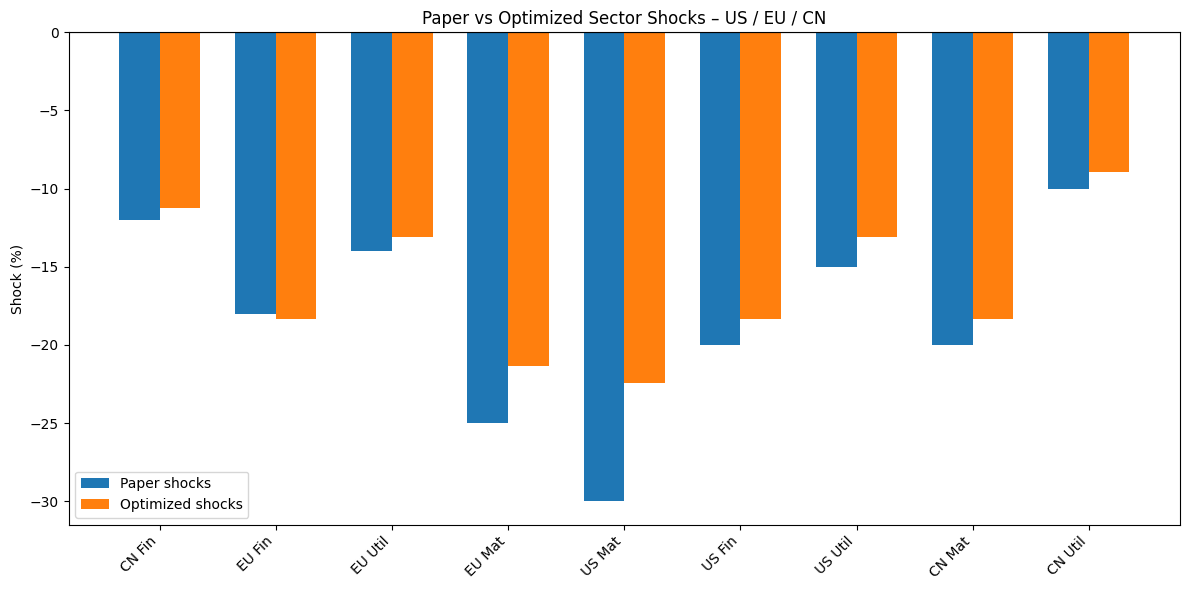

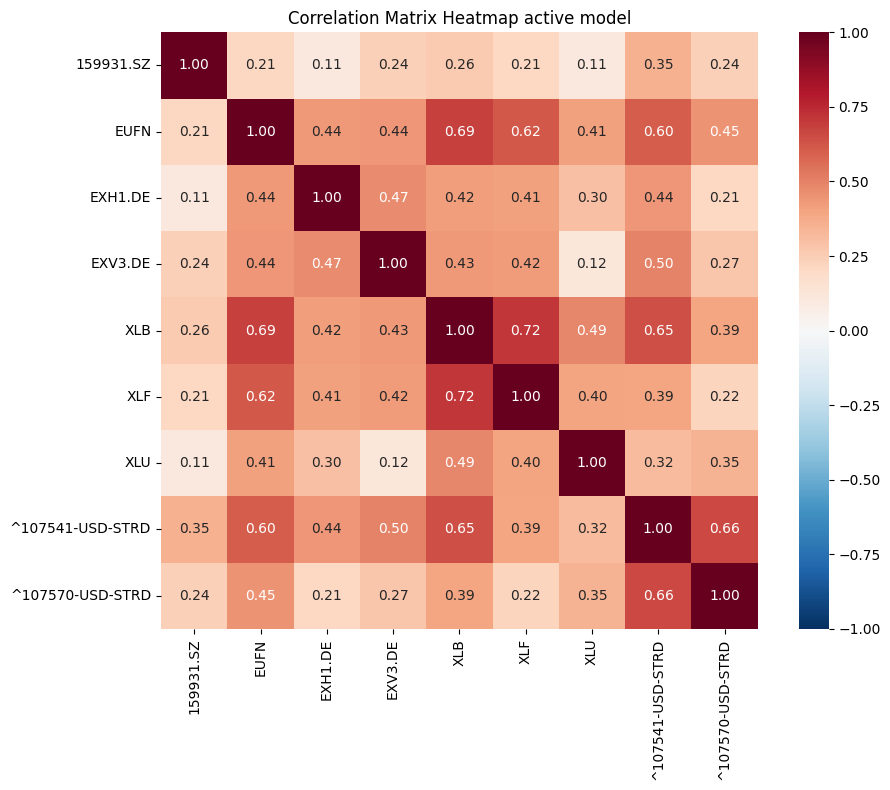

TypeError: robust_covariance_report() missing 2 required positional arguments: 'cov_parcv' and 'cov_graphLasso'

In [ ]:
"""
Main pipeline

"""

def main(cov_method="covPRCV"):
    prices = download_price_data(ALL_TICKERS)
    prices = prices.dropna(axis=1)

    rets = compute_log_returns(prices, freq='D')

    # Remove columns with (near) zero variance in returns —
    # these can cause identically zero correlations after shrinkage.
    var = rets.var(axis=0)

    # Convert daily variance to annual volatility (assume 252 trading days)
    ann_vol = np.sqrt(var) * np.sqrt(252)

    # Diagnostic prints: per-ticker annualized volatility and quick statistics
    print("Per-ticker annualized volatility (annual sigma):")
    print(ann_vol.apply(lambda x: f"{x:.2%}").to_dict())
    print(f"Min annual vol: {ann_vol.min():.2%}, Max annual vol: {ann_vol.max():.2%}")

    zero_var_cols = var[var <= 1e-12].index.tolist()
    if len(zero_var_cols) > 0:
        print("Removing near-zero-variance columns:", zero_var_cols)
        rets = rets.drop(columns=zero_var_cols)
        prices = prices.drop(columns=zero_var_cols, errors='ignore')

    # Active tickers after any removal
    active = list(rets.columns)

    # Base covariances 
    S_huber = cov_huber(rets)
    S_student, mu_student = cov_student_t(rets, nu=5.0, max_iter=100, tol=1e-6)
    


    cov_sample = cov_sample_(rets, decay=0.96)
    cov_sample_shrunk = cov_sample_ledoit(rets)
    cov_huber_shrunk = shrink_covariance(S_huber, shrinkage=0.1)
    cov_student_t_shrunk = shrink_covariance(S_student, shrinkage=0.1)
    cov_parcv = permutation_averaged_rcv(rets, K=200, train_frac=0.6)
    cov_graphLasso=cov_graphical_lasso(rets,alpha=0.01, max_iter=200)

    # Select the "active" model for scenario optimization
    
    if cov_method == "sample":
        cov = cov_sample
    elif cov_method == "huber":
        cov = cov_huber_shrunk
    elif cov_method == "student_t":
        cov = cov_student_t_shrunk
    elif cov_method == "shrunkLW":
        cov = cov_sample_shrunk
    elif cov_method=="covPRCV":
        cov=cov_parcv
    elif cov_method=="graphLasso":
        cov=cov_graphLasso
    else:
        raise ValueError("Invalid method")

    # Align paper shocks
    s0_full = build_paper_shocks()
    idx = {t: i for i, t in enumerate(ALL_TICKERS)}
    s0 = np.array([s0_full[idx[t]] for t in active])

    # Sanity checks for covariance matrix shape (help debug LinAlgError)
    cov_arr = np.asarray(cov)
    shapes = {
        'cov_selected_ndim': getattr(cov_arr, 'ndim', None),
        'cov_selected_shape': getattr(cov_arr, 'shape', None),
        'cov_sample_shape': getattr(cov_sample, 'shape', None),
        'cov_sample_shrunk_shape': getattr(cov_sample_shrunk, 'shape', None),
        'cov_huber_shrunk_shape': getattr(cov_huber_shrunk, 'shape', None),
        'cov_student_t_shape': getattr(cov_student_t_shrunk, 'shape', None),
        'cov_parcv_shape': getattr(cov_parcv, 'shape', None),
        'cov_graphLasso_shape': getattr(cov_graphLasso, 'shape', None),
        's0_shape': getattr(s0, 'shape', None)
    }
    if cov_arr.ndim != 2:
        raise RuntimeError(f"Selected covariance `cov` is not 2-D: {shapes}")
    if cov_arr.shape[0] != cov_arr.shape[1]:
        raise RuntimeError(f"Selected covariance `cov` is not square: {shapes}")
    if cov_arr.shape[0] != len(s0):
        raise RuntimeError(f"Covariance dimension {cov_arr.shape} does not match shock vector length {s0.shape}")

    cov = cov_arr

    # Scenario optimization
    r0_sq = s0.T @ np.linalg.solve(cov, s0)
    print("Mahalanobis (scenario, before optimization):", np.sqrt(r0_sq))
    s_opt, r2 = optimize_shocks(cov, s0, active)
    print("Mahalanobis (scenario, after optimization):", np.sqrt(r2))

    print("Trace Huber:", np.trace(S_huber))
    
    print("Min eigen Huber:", np.min(np.linalg.eigvalsh(S_huber)))
    

    Sigma_inv = np.linalg.inv(cov)
    summary = print_summary_table(active, s0, s_opt, Sigma_inv)

    plot_shock_comparison(active, s0, s_opt)
    plot_covariance_heatmap(cov, active, show_correlation=True)

    # Robustness report across models (include cov_parcv and cov_graphLasso)
    robust_covariance_report(rets, cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso)

    # Comparison plots (include sample sample covariance)
    plot_corr_heatmaps_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso, active)
    plot_eigenvalues_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso)
    plot_avg_correlations_3(cov_sample, cov_sample_shrunk, cov_huber_shrunk, cov_student_t_shrunk, cov_parcv, cov_graphLasso)



    # Ellipses / surfaces for the active model
    i = active.index("XLB")
    j = active.index("EXV3.DE")

    #plot_mahalanobis_ellipse_single(cov, active, i, j, f"Ellipse {cov_method}")
    plot_mahalanobis_surface_single(cov, active, i, j, f"Surface {cov_method}")

    # Scenario Plausibility Index for the active model
    pl = compute_plausibility_index(s_opt, cov, rets, active)
    print("\nScenario Plausibility Index (active model):")
    for k, v in pl.items():
        print(f"  {k}: {v:.4f}")

    # Interactive dashboard (existing)
    dashboard_covariance_mahalanobis(
        cov_sample,
        cov_sample_shrunk,
        cov_huber_shrunk,
        cov_student_t_shrunk,
        rets,
        s_opt,
        pl,
        active
    )
    
    # Call the top-level animation helper and display it (will render in Jupyter)
    try:
        display_obj = animate_mahalanobis(rets, cov, tickers=active, train_frac=0.25, interval=40)
        try:
            from IPython.display import display
            display(display_obj)
        except Exception:
            print("Animation created (use to_jshtml()); render in Jupyter to view")
    except Exception as e:
        print("Animation skipped or failed:", e)
        

    return {
        "cov_sample": cov_sample,
        "cov_sample_shrunk": cov_sample_shrunk,
        "cov_huber_shrunk": cov_huber_shrunk,
        "cov_student_t": cov_student_t_shrunk,
        "cov_active": cov,
        "s_opt": s_opt,
        "summary": summary,
        "plausibility": pl
    }




if __name__ == "__main__":
     results = main(cov_method="covPRCV")
